# DBSCAN sur données réduites par PCA

## 1. Chargement et préparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

data = pd.read_csv("../data/marketing_campaign_cleaned.csv")
df = data.copy()

features = ['Income', 'Recency', 'TotalMnt', 'TotalPurchases', 'TotalChildren']
X_scaled = df[features]

print("Shape original:", X_scaled.shape)

Shape original: (2213, 5)


## 2. Réduction dimensionnelle par PCA
On choisit le nombre de composantes qui expliquent >= 80% de la variance

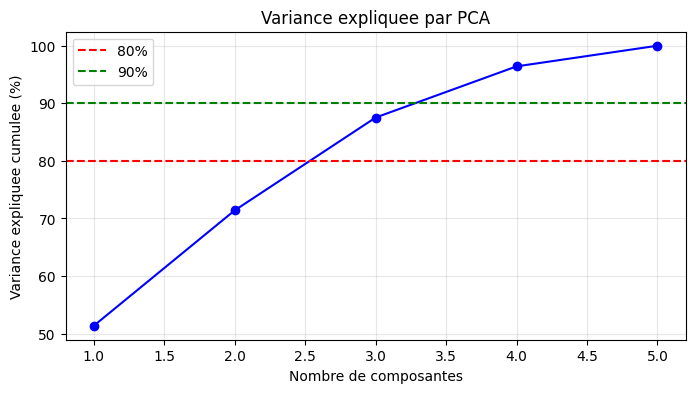

  1 composante(s) -> 51.4% variance expliquee
  2 composante(s) -> 71.4% variance expliquee
  3 composante(s) -> 87.5% variance expliquee
  4 composante(s) -> 96.4% variance expliquee
  5 composante(s) -> 100.0% variance expliquee

-> On choisit 3 composantes (>= 80% variance)


In [2]:
pca_full = PCA()
pca_full.fit(X_scaled)

variance_cumul = np.cumsum(pca_full.explained_variance_ratio_) * 100

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(variance_cumul)+1), variance_cumul, 'bo-')
plt.axhline(y=80, color='r', linestyle='--', label='80%')
plt.axhline(y=90, color='g', linestyle='--', label='90%')
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance expliquee cumulee (%)')
plt.title('Variance expliquee par PCA')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

for i, v in enumerate(variance_cumul):
    print(f"  {i+1} composante(s) -> {v:.1f}% variance expliquee")

n_components = next(i+1 for i, v in enumerate(variance_cumul) if v >= 80)
print(f"\n-> On choisit {n_components} composantes (>= 80% variance)")

In [3]:
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

print(f"Shape apres PCA : {X_pca.shape}")
print(f"Variance expliquee : {pca.explained_variance_ratio_.sum()*100:.1f}%")

Shape apres PCA : (2213, 3)
Variance expliquee : 87.5%


## 3. Trouver le bon eps via la courbe k-distance

min_samples : 6


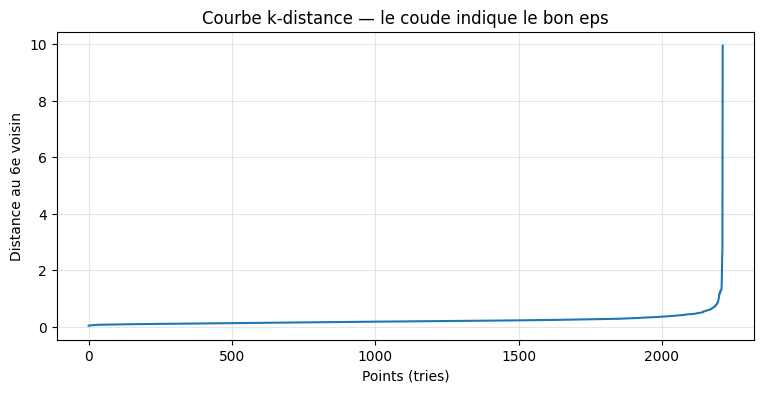

Mediane    : 0.1918
75e pctile : 0.2517
90e pctile : 0.3526


In [4]:
min_samples = 2 * n_components
print(f"min_samples : {min_samples}")

nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_pca)
distances, _ = nbrs.kneighbors(X_pca)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(9, 4))
plt.plot(distances)
plt.xlabel('Points (tries)')
plt.ylabel(f'Distance au {min_samples}e voisin')
plt.title('Courbe k-distance — le coude indique le bon eps')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Mediane    : {np.median(distances):.4f}")
print(f"75e pctile : {np.percentile(distances, 75):.4f}")
print(f"90e pctile : {np.percentile(distances, 90):.4f}")

## 4. Grille automatique — tester 25 valeurs d'eps

In [5]:
p50 = np.percentile(distances, 50)
p95 = np.percentile(distances, 95)
eps_values = np.linspace(p50 * 0.5, p95 * 1.2, 25)

results = []
for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_pca)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    pct_noise = n_noise / len(labels) * 100

    score = None
    if n_clusters >= 2:
        mask = labels != -1
        if len(set(labels[mask])) >= 2:
            score = silhouette_score(X_pca[mask], labels[mask])

    results.append({
        'eps': round(eps, 4),
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'pct_noise': round(pct_noise, 1),
        'silhouette': round(score, 4) if score else None
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

   eps  n_clusters  n_noise  pct_noise  silhouette
0.0959          28     1893       85.5      0.5078
0.1145          31     1679       75.9      0.3160
0.1331          48     1417       64.0      0.2487
0.1516          51     1214       54.9      0.1416
0.1702          58      989       44.7      0.1368
0.1888          61      720       32.5      0.0301
0.2073          37      563       25.4     -0.1159
0.2259          19      439       19.8     -0.1967
0.2445          18      327       14.8     -0.1676
0.2631          13      264       11.9     -0.0894
0.2816          12      238       10.8     -0.0791
0.3002          16      183        8.3     -0.1068
0.3188          15      160        7.2     -0.1160
0.3373          13      142        6.4     -0.0636
0.3559          12      119        5.4     -0.0528
0.3745          10      105        4.7     -0.0165
0.3931           9       84        3.8     -0.0071
0.4116           7       77        3.5      0.1047
0.4302           7       64    

## 5. Selection du meilleur eps

In [6]:
valid = results_df[
    (results_df['n_clusters'] >= 2) &
    (results_df['pct_noise'] < 20) &
    (results_df['silhouette'].notna())
]

if valid.empty:
    valid = results_df[
        (results_df['n_clusters'] >= 2) &
        (results_df['silhouette'].notna())
    ]

best = valid.loc[valid['silhouette'].idxmax()]
best_eps = best['eps']

print(f"Meilleur eps      : {best_eps}")
print(f"Nb clusters       : {int(best['n_clusters'])}")
print(f"Bruit             : {best['pct_noise']}%")
print(f"Silhouette Score  : {best['silhouette']}")

Meilleur eps      : 0.4116
Nb clusters       : 7
Bruit             : 3.5%
Silhouette Score  : 0.1047


## 6. Clustering final

In [7]:
db_final = DBSCAN(eps=best_eps, min_samples=min_samples)
df["Cluster"] = db_final.fit_predict(X_pca)

n_clusters = len(set(df["Cluster"])) - (1 if -1 in df["Cluster"].values else 0)
n_noise = (df["Cluster"] == -1).sum()

mask = df["Cluster"] != -1
score_final = silhouette_score(X_pca[mask], df["Cluster"][mask])

print(f"Nb clusters    : {n_clusters}")
print(f"Points bruit   : {n_noise} ({n_noise/len(df)*100:.1f}%)")
print(f"Silhouette     : {score_final:.4f}")
print(f"\nDistribution :")
print(df["Cluster"].value_counts().sort_index())

Nb clusters    : 7
Points bruit   : 77 (3.5%)
Silhouette     : 0.1047

Distribution :
Cluster
-1      77
 0     485
 1     383
 2    1103
 3     139
 4       9
 5       6
 6      11
Name: count, dtype: int64


## 7. Profil des clusters

In [8]:
profil = df.groupby("Cluster")[features].mean().round(3)
profil.index = ['Bruit (outliers)' if i == -1 else f'Cluster {i}' for i in profil.index]
print(profil)

                  Income  Recency  TotalMnt  TotalPurchases  TotalChildren
Bruit (outliers)   0.759    0.140     0.464           0.718          1.390
Cluster 0          0.928    0.011     1.262           0.680         -1.264
Cluster 1         -0.369   -0.001    -0.697          -0.483          1.407
Cluster 2         -0.212   -0.007    -0.236          -0.065          0.072
Cluster 3         -0.919   -0.019    -0.745          -0.858         -1.264
Cluster 4         -0.164    1.119    -0.864          -0.941          2.743
Cluster 5          0.308   -1.567     0.175           1.645          1.407
Cluster 6         -0.552   -0.538    -0.929          -1.016          2.743


## 8. Visualisation PCA 2D

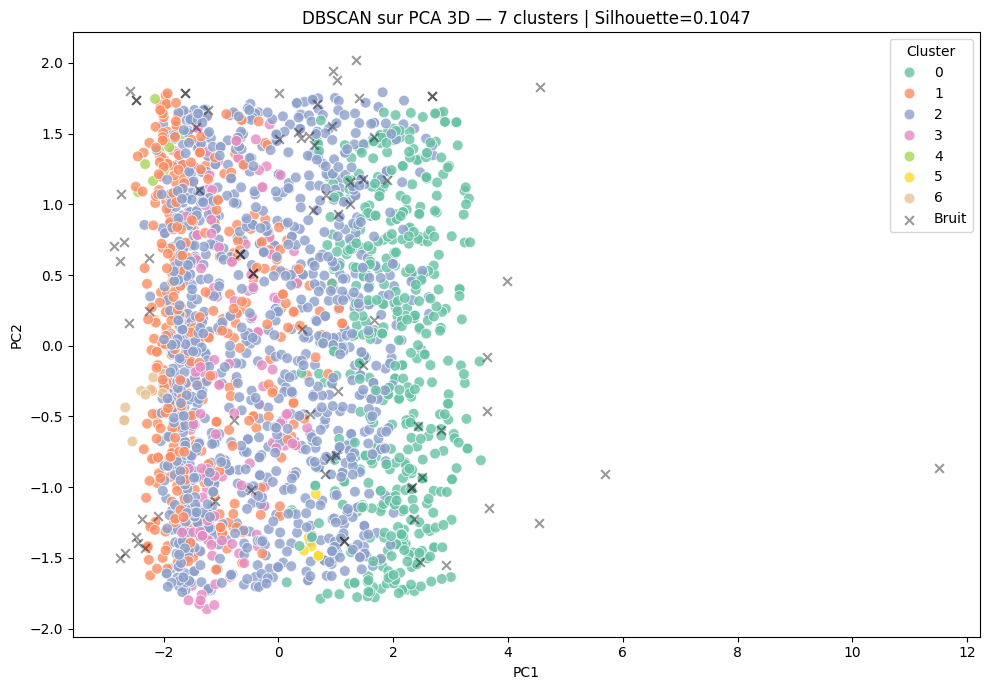

Variance expliquee PC1+PC2 (visu) : 71.4%


In [9]:
# Reduire a 2D pour la visualisation
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_2d, columns=["PC1", "PC2"])
pca_df["Cluster"] = df["Cluster"].values

normal = pca_df[pca_df["Cluster"] != -1]
bruit  = pca_df[pca_df["Cluster"] == -1]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x="PC1", y="PC2", hue="Cluster",
    data=normal, palette="Set2", alpha=0.8, s=60
)
if len(bruit) > 0:
    plt.scatter(
        bruit["PC1"], bruit["PC2"],
        c='black', marker='x', s=40, alpha=0.4, label='Bruit'
    )
plt.legend(title='Cluster')
plt.title(f"DBSCAN sur PCA {n_components}D — {n_clusters} clusters | Silhouette={score_final:.4f}")
plt.tight_layout()
plt.show()

v2d = pca_2d.explained_variance_ratio_.sum() * 100
print(f"Variance expliquee PC1+PC2 (visu) : {v2d:.1f}%")